In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据（路径换成你自己的）
df = pd.read_csv('C:/Users/Lenovo/Desktop/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"数据量：{df.shape[0]} 行，{df.shape[1]} 列")
print("\n前5行数据：")
df.head()

数据量：7043 行，21 列

前5行数据：


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
print("流失分布：")
print(df['Churn'].value_counts())
print(f"\n流失率：{df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

流失分布：
Churn
No     5174
Yes    1869
Name: count, dtype: int64

流失率：26.5%


In [4]:
# 1. TotalCharges 应该是数值，但现在它被识别为了对象(object)
#    因为里面混入了空字符串。我们强行转换，空字符串会变成 NaN，然后填 0。
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. 看看哪里有缺失值
print("缺失值情况：")
print(df.isnull().sum())

# 3. TotalCharges 为空的，通常是新用户，tenure为0，总费用也确实应该是0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("\n缺失值已处理，当前缺失值总数：", df.isnull().sum().sum())

缺失值情况：
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

缺失值已处理，当前缺失值总数： 0


In [5]:
# 1. 将目标变量 Churn 转成 1 (流失) 和 0 (未流失)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. 筛选出那些只有 'Yes'/'No' 两种值的列，一键批量转换
binary_cols = []
for col in df.columns:
    if set(df[col].unique()) == {'Yes', 'No'}:
        binary_cols.append(col)

print(f"检测到以下二分类变量：{binary_cols}")

# 批量转成 1/0
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# 3. 验证转换效果
df[binary_cols].head()

检测到以下二分类变量：['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']


,Partner,Dependents,PhoneService,PaperlessBilling
0,1,0,0,1
1,0,0,1,0
2,0,0,1,1
3,0,0,0,0
4,0,0,1,1


In [6]:
# 1. 找出剩余的非数值列（排除客户ID和目标变量）
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'customerID' in obj_cols:
    obj_cols.remove('customerID')

print(f"需要进行独热编码的列：{obj_cols}")

# 2. 执行独热编码
df = pd.get_dummies(df, columns=obj_cols, drop_first=True)

print(f"编码后数据维度：{df.shape[0]} 行，{df.shape[1]} 列")
df.head(3)

需要进行独热编码的列：['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
编码后数据维度：7043 行，32 列


,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True


In [8]:
# 查看当前所有列名，方便我们挑出服务列
all_columns = df.columns.tolist()
print("当前数据框的列名（部分）：")
print([col for col in all_columns if 'Online' in col or 'Phone' in col or 'Multiple' in col])

当前数据框的列名（部分）：
['PhoneService', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes']


In [9]:
# 重新定义 ServiceCount：找到所有代表“开通某服务”的列，并把它们的值加起来
service_yes_cols = []

# 1. PhoneService 已经是 0/1，列名没变
if 'PhoneService' in df.columns:
    service_yes_cols.append('PhoneService')

# 2. MultipleLines 独热编码后，代表开通的是 'MultipleLines_Yes'
if 'MultipleLines_Yes' in df.columns:
    service_yes_cols.append('MultipleLines_Yes')

# 3. InternetService 开通的表现是有 DSL 或 Fiber optic，这两列都是 1 代表开通
for col in ['InternetService_DSL', 'InternetService_Fiber optic']:
    if col in df.columns:
        service_yes_cols.append(col)

# 4. 其他在线服务：OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies
#    它们独热编码后，代表“Yes”的列通常以 _Yes 结尾
other_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                  'TechSupport', 'StreamingTV', 'StreamingMovies']
for service in other_services:
    col_name = service + '_Yes'
    if col_name in df.columns:
        service_yes_cols.append(col_name)

print(f"\n参与 ServiceCount 计算的列：{service_yes_cols}")

# 计算每个用户开通的服务总数
df['ServiceCount'] = df[service_yes_cols].sum(axis=1)

# 后面两个衍生特征不变（如果之前已经生成，可以跳过，但再运行一次也没事）
df['TenureGroup'] = pd.cut(df['tenure'], bins=[-1, 6, 12, 24, 48, np.inf], 
                           labels=['0-6月', '7-12月', '13-24月', '25-48月', '48月+'])

df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

print(f"'ServiceCount' 取值范围: {df['ServiceCount'].min()} ~ {df['ServiceCount'].max()}")
print(f"'AvgMonthlySpend' 均值: {df['AvgMonthlySpend'].mean():.2f}")


参与 ServiceCount 计算的列：['PhoneService', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']
'ServiceCount' 取值范围: 0 ~ 9
'AvgMonthlySpend' 均值: 58.99


In [10]:
print(f"最终数据维度：{df.shape}")
print(f"流失率检查：{df['Churn'].mean():.1%} (应该还是 26.5% 左右)")
df.head()

最终数据维度：(7043, 35)
流失率检查：26.5% (应该还是 26.5% 左右)


,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,ServiceCount,TenureGroup,AvgMonthlySpend
0,7590-VHVEG,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,True,False,1,0-6月,14.925000
1,5575-GNVDE,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,True,False,False,False,True,3,25-48月,53.985714
2,3668-QPYBK,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,True,3,0-6月,36.050000
3,7795-CFOCW,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,True,False,False,False,False,3,25-48月,40.016304
4,9237-HQITU,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,True,False,2,0-6月,50.550000


In [25]:
# 修复数据类型：确保所有特征都是数值型
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)  # 如果转换产生 NaN，填 0（安全起见）
print(f"X 数据类型检查：\n{X.dtypes.value_counts()}")

X 数据类型检查：
bool       22
int64       7
float64     3
Name: count, dtype: int64


In [26]:
from sklearn.model_selection import train_test_split

# 排除ID列、目标列、以及我们刚创建的衍生分类列（TenureGroup还没编码，先按数值用）
# 但其实TenureGroup是category类型，需要先转成数值，或者我们就直接扔掉，因为tenure已经在特征里了。
# 简便起见：我们移除 customerID, Churn 以及 TenureGroup（类别型，后面可再优化）
drop_cols = ['customerID', 'Churn', 'TenureGroup']
X = df.drop(columns=drop_cols, errors='ignore')
y = df['Churn']

print(f"特征矩阵形状: {X.shape}")
print(f"目标变量分布:\n{y.value_counts()}")

特征矩阵形状: (7043, 32)
目标变量分布:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"训练集: {X_train.shape[0]} 条，流失率 {y_train.mean():.1%}")
print(f"测试集: {X_test.shape[0]} 条，流失率 {y_test.mean():.1%}")

训练集: 4930 条，流失率 26.5%
测试集: 2113 条，流失率 26.5%


In [28]:
!pip install lightgbm imbalanced-learn -q

In [29]:
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

In [30]:
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

print(f"SMOTE 后训练集: {X_train_resampled.shape[0]} 条，流失率 {y_train_resampled.mean():.1%}")

SMOTE 后训练集: 7244 条，流失率 50.0%


In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

In [33]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train_resampled)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_resampled, y_train_resampled)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'AUC': auc,
        'Classification Report': classification_report(y_test, y_pred, target_names=['未流失', '流失'])
    }
    print(f"\n{'='*50}")
    print(f"📊 {name}  AUC: {auc:.4f}")
    print(f"{'='*50}")
    print(results[name]['Classification Report'])


📊 Logistic Regression  AUC: 0.8350
              precision    recall  f1-score   support

         未流失       0.86      0.85      0.86      1552
          流失       0.60      0.61      0.61       561

    accuracy                           0.79      2113
   macro avg       0.73      0.73      0.73      2113
weighted avg       0.79      0.79      0.79      2113


📊 Random Forest  AUC: 0.8119
              precision    recall  f1-score   support

         未流失       0.85      0.85      0.85      1552
          流失       0.58      0.58      0.58       561

    accuracy                           0.78      2113
   macro avg       0.71      0.71      0.71      2113
weighted avg       0.78      0.78      0.78      2113



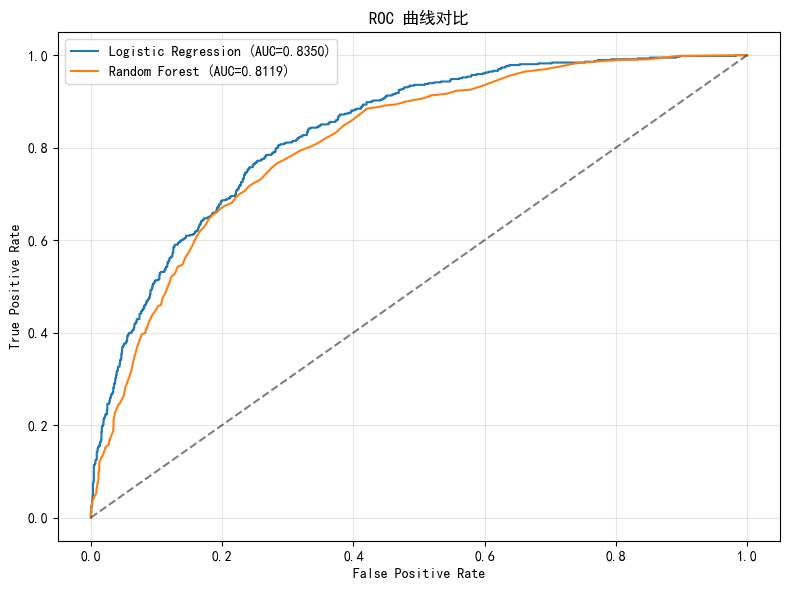

In [19]:
plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['AUC']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC 曲线对比')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Churn_ROC.png', dpi=150)
plt.show()

逻辑回归 AUC: 0.8331
              precision    recall  f1-score   support

         未流失       0.86      0.85      0.85      1552
          流失       0.59      0.63      0.61       561

    accuracy                           0.79      2113
   macro avg       0.73      0.74      0.73      2113
weighted avg       0.79      0.79      0.79      2113



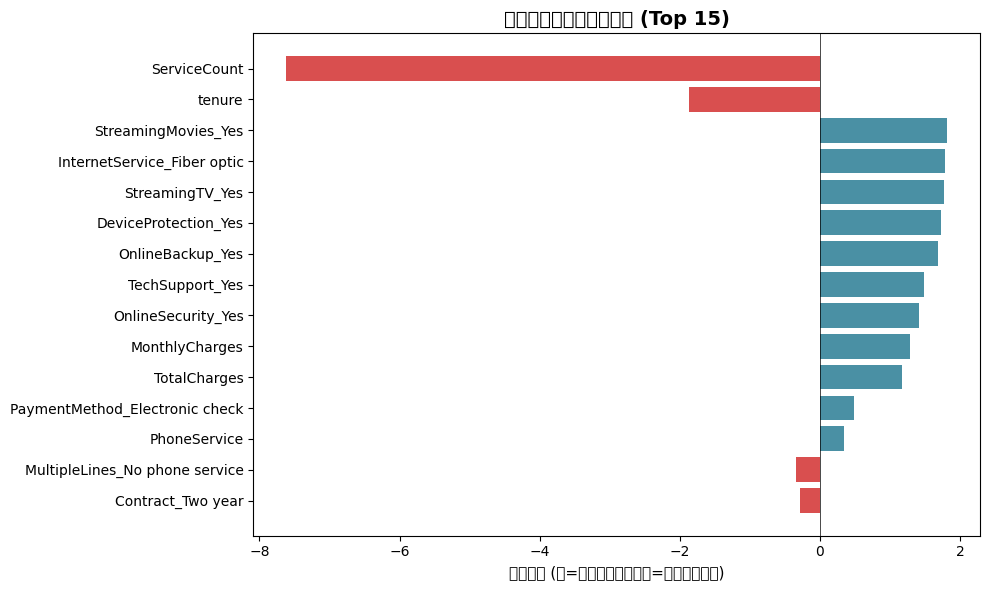


Top 15 特征系数：
                           feature  coefficient
30                    ServiceCount    -7.616974
3                           tenure    -1.874058
24             StreamingMovies_Yes     1.814341
11     InternetService_Fiber optic     1.792630
22                 StreamingTV_Yes     1.776410
18            DeviceProtection_Yes     1.734884
16                OnlineBackup_Yes     1.682153
20                 TechSupport_Yes     1.483811
14              OnlineSecurity_Yes     1.416592
6                   MonthlyCharges     1.284133
7                     TotalCharges     1.176126
28  PaymentMethod_Electronic check     0.484189
4                     PhoneService     0.347110
9   MultipleLines_No phone service    -0.347110
26               Contract_Two year    -0.283313


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ---------- 1. 读取数据 ----------
df = pd.read_csv('C:/Users/Lenovo/Desktop/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# ---------- 2. 数据清洗 ----------
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 二分类变量转 0/1
binary_cols = [col for col in df.columns if set(df[col].unique()) == {'Yes', 'No'}]
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# 多分类变量独热编码
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'customerID' in obj_cols:
    obj_cols.remove('customerID')
df = pd.get_dummies(df, columns=obj_cols, drop_first=True)

# 衍生特征
service_cols = []
if 'PhoneService' in df.columns:
    service_cols.append('PhoneService')
for col in df.columns:
    if col.endswith('_Yes') and 'Multiple' not in col:
        service_cols.append(col)
for col in ['InternetService_DSL', 'InternetService_Fiber optic']:
    if col in df.columns:
        service_cols.append(col)
df['ServiceCount'] = df[service_cols].sum(axis=1)

# ---------- 3. 准备特征 ----------
drop_cols = ['customerID', 'Churn']
X = df.drop(columns=drop_cols, errors='ignore')
y = df['Churn']
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# ---------- 4. 划分训练/测试 ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# ---------- 5. 训练逻辑回归 ----------
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_res)
y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f'逻辑回归 AUC: {auc:.4f}')
print(classification_report(y_test, y_pred, target_names=['未流失', '流失']))

# ---------- 6. 特征系数分析 ----------
coefficients = lr.coef_[0]
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': coefficients,
    'abs_coef': np.abs(coefficients)
}).sort_values('abs_coef', ascending=False)

top15 = coef_df.head(15)

plt.figure(figsize=(10, 6))
colors = ['#D94F4F' if c < 0 else '#4A90A4' for c in top15['coefficient']]
plt.barh(top15['feature'][::-1], top15['coefficient'][::-1], color=colors[::-1])
plt.axvline(x=0, color='black', linewidth=0.5)
plt.xlabel('回归系数 (负=降低流失风险，正=增加流失风险)', fontsize=11)
plt.title('逻辑回归特征重要性排名 (Top 15)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('LR_Coefficients.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nTop 15 特征系数：")
print(top15[['feature', 'coefficient']])

In [2]:
# ---------- 7. 运营策略模拟 ----------
import numpy as np

# 业务参数
retention_cost = 5  # 每人干预成本
ltv_factor = 12     # 挽留成功可获得未来12个月月费（可根据实际调整）

# 恢复原始测试集的月费（MonthlyCharges）来估算LTV
# 注意：X_test 列中有 MonthlyCharges 这一原始特征
monthly_charges_test = X_test['MonthlyCharges'].values
ltv_per_user = monthly_charges_test * ltv_factor

# 预测概率
y_proba_test = lr.predict_proba(X_test_scaled)[:, 1]

# 真实标签
y_true = y_test.values

# 模拟不同概率阈值下的干预策略
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
results_list = []

for thresh in thresholds:
    # 判定为“会流失”的用户（预测概率 > 阈值）
    predicted_positive = y_proba_test >= thresh
    # 真正会流失的用户（真实标签为1）
    true_positive = y_true == 1
    
    # 我们干预的用户数
    num_targeted = predicted_positive.sum()
    # 干预后成功挽留的用户：真实流失且被我们预测到了（假设这些用户接受到挽留后成功留存）
    # 保守假设：我们只能挽留一部分（例如挽留成功率 100% 或更低），这里先假定100%成功，便于计算最大收益
    num_retained = (predicted_positive & true_positive).sum()
    
    # 总挽留收益：挽留住的用户带来的LTV总和
    total_ltv_gain = ltv_per_user[predicted_positive & true_positive].sum()
    # 总干预成本
    total_cost = num_targeted * retention_cost
    # 净收益
    net_profit = total_ltv_gain - total_cost
    
    results_list.append({
        '阈值': thresh,
        '触达用户数': num_targeted,
        '成功挽留数': num_retained,
        '总收益(£)': total_ltv_gain,
        '总成本(£)': total_cost,
        '净收益(£)': net_profit
    })

results_df = pd.DataFrame(results_list)
print("不同干预阈值下的成本收益模拟：")
print(results_df.to_string(index=False))

# 找出最优阈值
best_row = results_df.loc[results_df['净收益(£)'].idxmax()]
print(f"\n最优阈值：{best_row['阈值']}，预计净收益 £{best_row['净收益(£)']:,.0f}")

不同干预阈值下的成本收益模拟：
 阈值  触达用户数  成功挽留数   总收益(£)  总成本(£)   净收益(£)
0.3    961    463 410896.8    4805 406091.8
0.4    770    408 365605.2    3850 361755.2
0.5    591    351 322245.6    2955 319290.6
0.6    434    279 257065.8    2170 254895.8
0.7    266    186 172222.2    1330 170892.2
0.8    100     77  74272.8     500  73772.8

最优阈值：0.3，预计净收益 £406,092
